# Study Notes: Long Short-Term Memory (LSTM) - Part 1 (The What?)

---

## 1. Introduction

### What is LSTM?
**LSTM** stands for **Long Short-Term Memory**. It is a special type of Recurrent Neural Network (RNN) architecture designed to handle **long sequences** of data effectively.

### Why is it important?
- LSTM is **widely used in the industry** for sequential data tasks like:
  - Natural Language Processing (NLP)
  - Time series forecasting
  - Speech recognition
  - Machine translation
- **Crucial foundation**: Modern AI systems like **Transformers** (used in ChatGPT, BERT, etc.) have their foundational steps rooted in RNNs and LSTMs. Understanding LSTMs is essential for grasping advanced topics like Large Language Models (LLMs).

### Real-life use
- **Sentiment analysis** – determining if a movie review is positive or negative
- **Language translation** – converting English to Hindi while maintaining context
- **Stock price prediction** – using past prices to forecast future trends
- **Text generation** – predicting the next word in a sentence

---

## 2. Detailed Explanation

### Recap: The Problem with Simple RNNs

**Sequential Data** – Data where **order matters** (e.g., text, time series, audio).

#### Why can't a simple Neural Network handle sequences?
A basic neural network takes all inputs together as one vector. For a sentence like *"My name is Nitish"*, if you send all words at once, the order is lost. The network cannot tell which word came first.

#### How does a Simple RNN solve this?
RNNs process data **one word at a time** and maintain a **state** (hidden state) that carries information from previous steps.

**RNN concept:**
- Input at time `t` = current word
- Hidden state at time `t-1` = memory from previous words
- Hidden state at time `t` = new updated memory
- This hidden state is passed to the next time step

```
Word1 → [State] → Word2 → [State] → Word3 → ... → Output
```

#### The Vanishing/Exploding Gradient Problem
When sequences become **very long** (e.g., 50+ words), simple RNNs **forget** the early inputs.

**Example:**
> *"Maharashtra is a beautiful state, it has 25 cities, it has beautiful vegetation, forests and ... (many sentences later) ... language spoken here is _______"*

- The correct answer is **Marathi** (based on the first word "Maharashtra")
- But a simple RNN may have **forgotten** "Maharashtra" by the end
- This happens due to **vanishing gradients** – the influence of early inputs diminishes as you go further down the sequence

---

### The Core Idea of LSTM

LSTM was invented to solve this **long-term dependency problem**.

#### The Story Analogy

Imagine you are listening to a story and must decide if it is **good** or **bad**. Your brain processes the story **word by word** and does two things simultaneously:

1. **Short-term context** – What is happening right now?
2. **Long-term context** – What is important for the entire story?

**Your brain's process:**
- You keep important characters in your **long-term memory**
- You **remove** characters that are no longer relevant
- You **add** new important characters as they appear

**The Story:**
> *"Pratapgarh is a very old state. Vikram is the king – powerful and good. Then King X attacked. Vikram fought bravely but was killed. Then Vikram Junior came – even more powerful. But he was also killed. Then Vikram Super Junior came – not as strong but very smart. He used his brain and killed King X, avenging his family."*

**How you decided it was a good story:**
| Character | Action in Your Brain |
|-----------|----------------------|
| Pratapgarh | Added to long-term context (setting matters in history) |
| Vikram (original) | Added → then **removed** when killed |
| Vikram Junior | Added → then **removed** when killed |
| Vikram Super Junior | Added → **kept** because he succeeded |
| King X | Kept as the villain throughout |

---

### The LSTM Solution: Two Separate Memories

#### Problem with Simple RNN:
- Only **one state** (hidden state) must carry **both** short-term AND long-term context
- Short-term context **dominates** – long-term gets forgotten

#### LSTM Innovation:
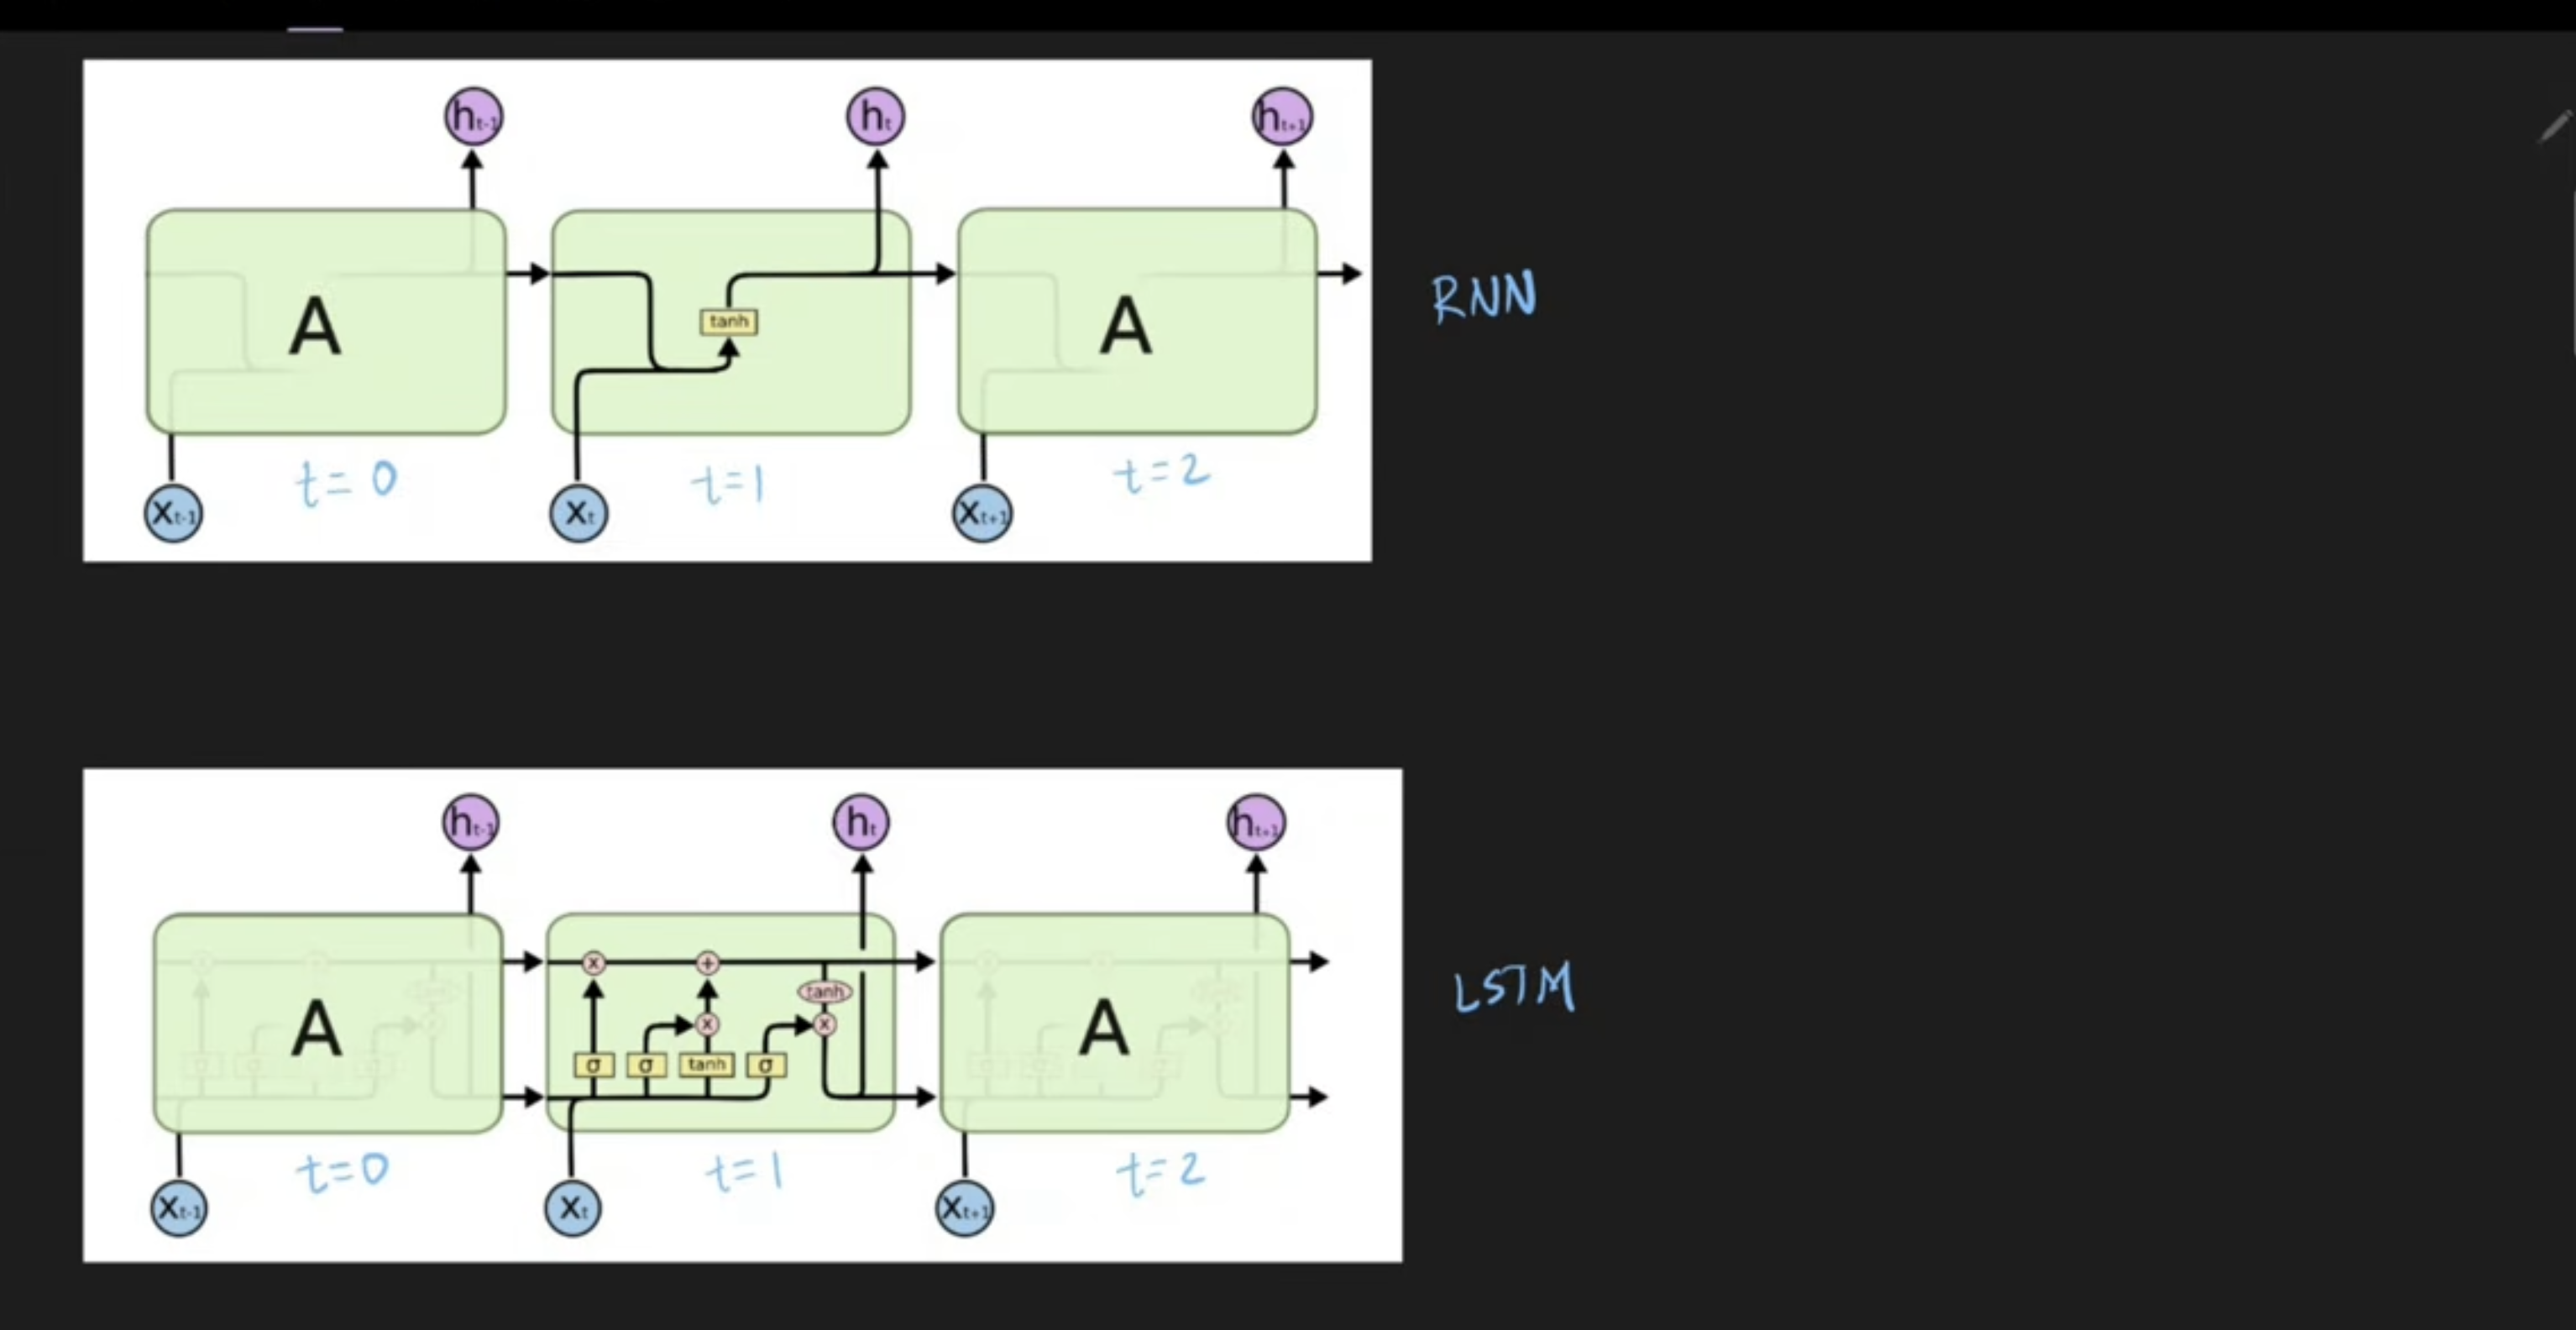
- **Two separate memory lines:**
  1. **Short-term memory** (hidden state, lower line) – keeps recent context
  2. **Long-term memory** (cell state, upper line) – keeps important information from far back

**Visual analogy:**
- Long-term memory = a **highway** where important information travels freely
- Short-term memory = a **service road** with recent details
- They **communicate** with each other to decide what to keep, remove, or add

**Key advantage:** If something is important at the first step, it can travel through the long-term memory line all the way to the final output – as long as it's never removed.

---

### The Three Gates of LSTM
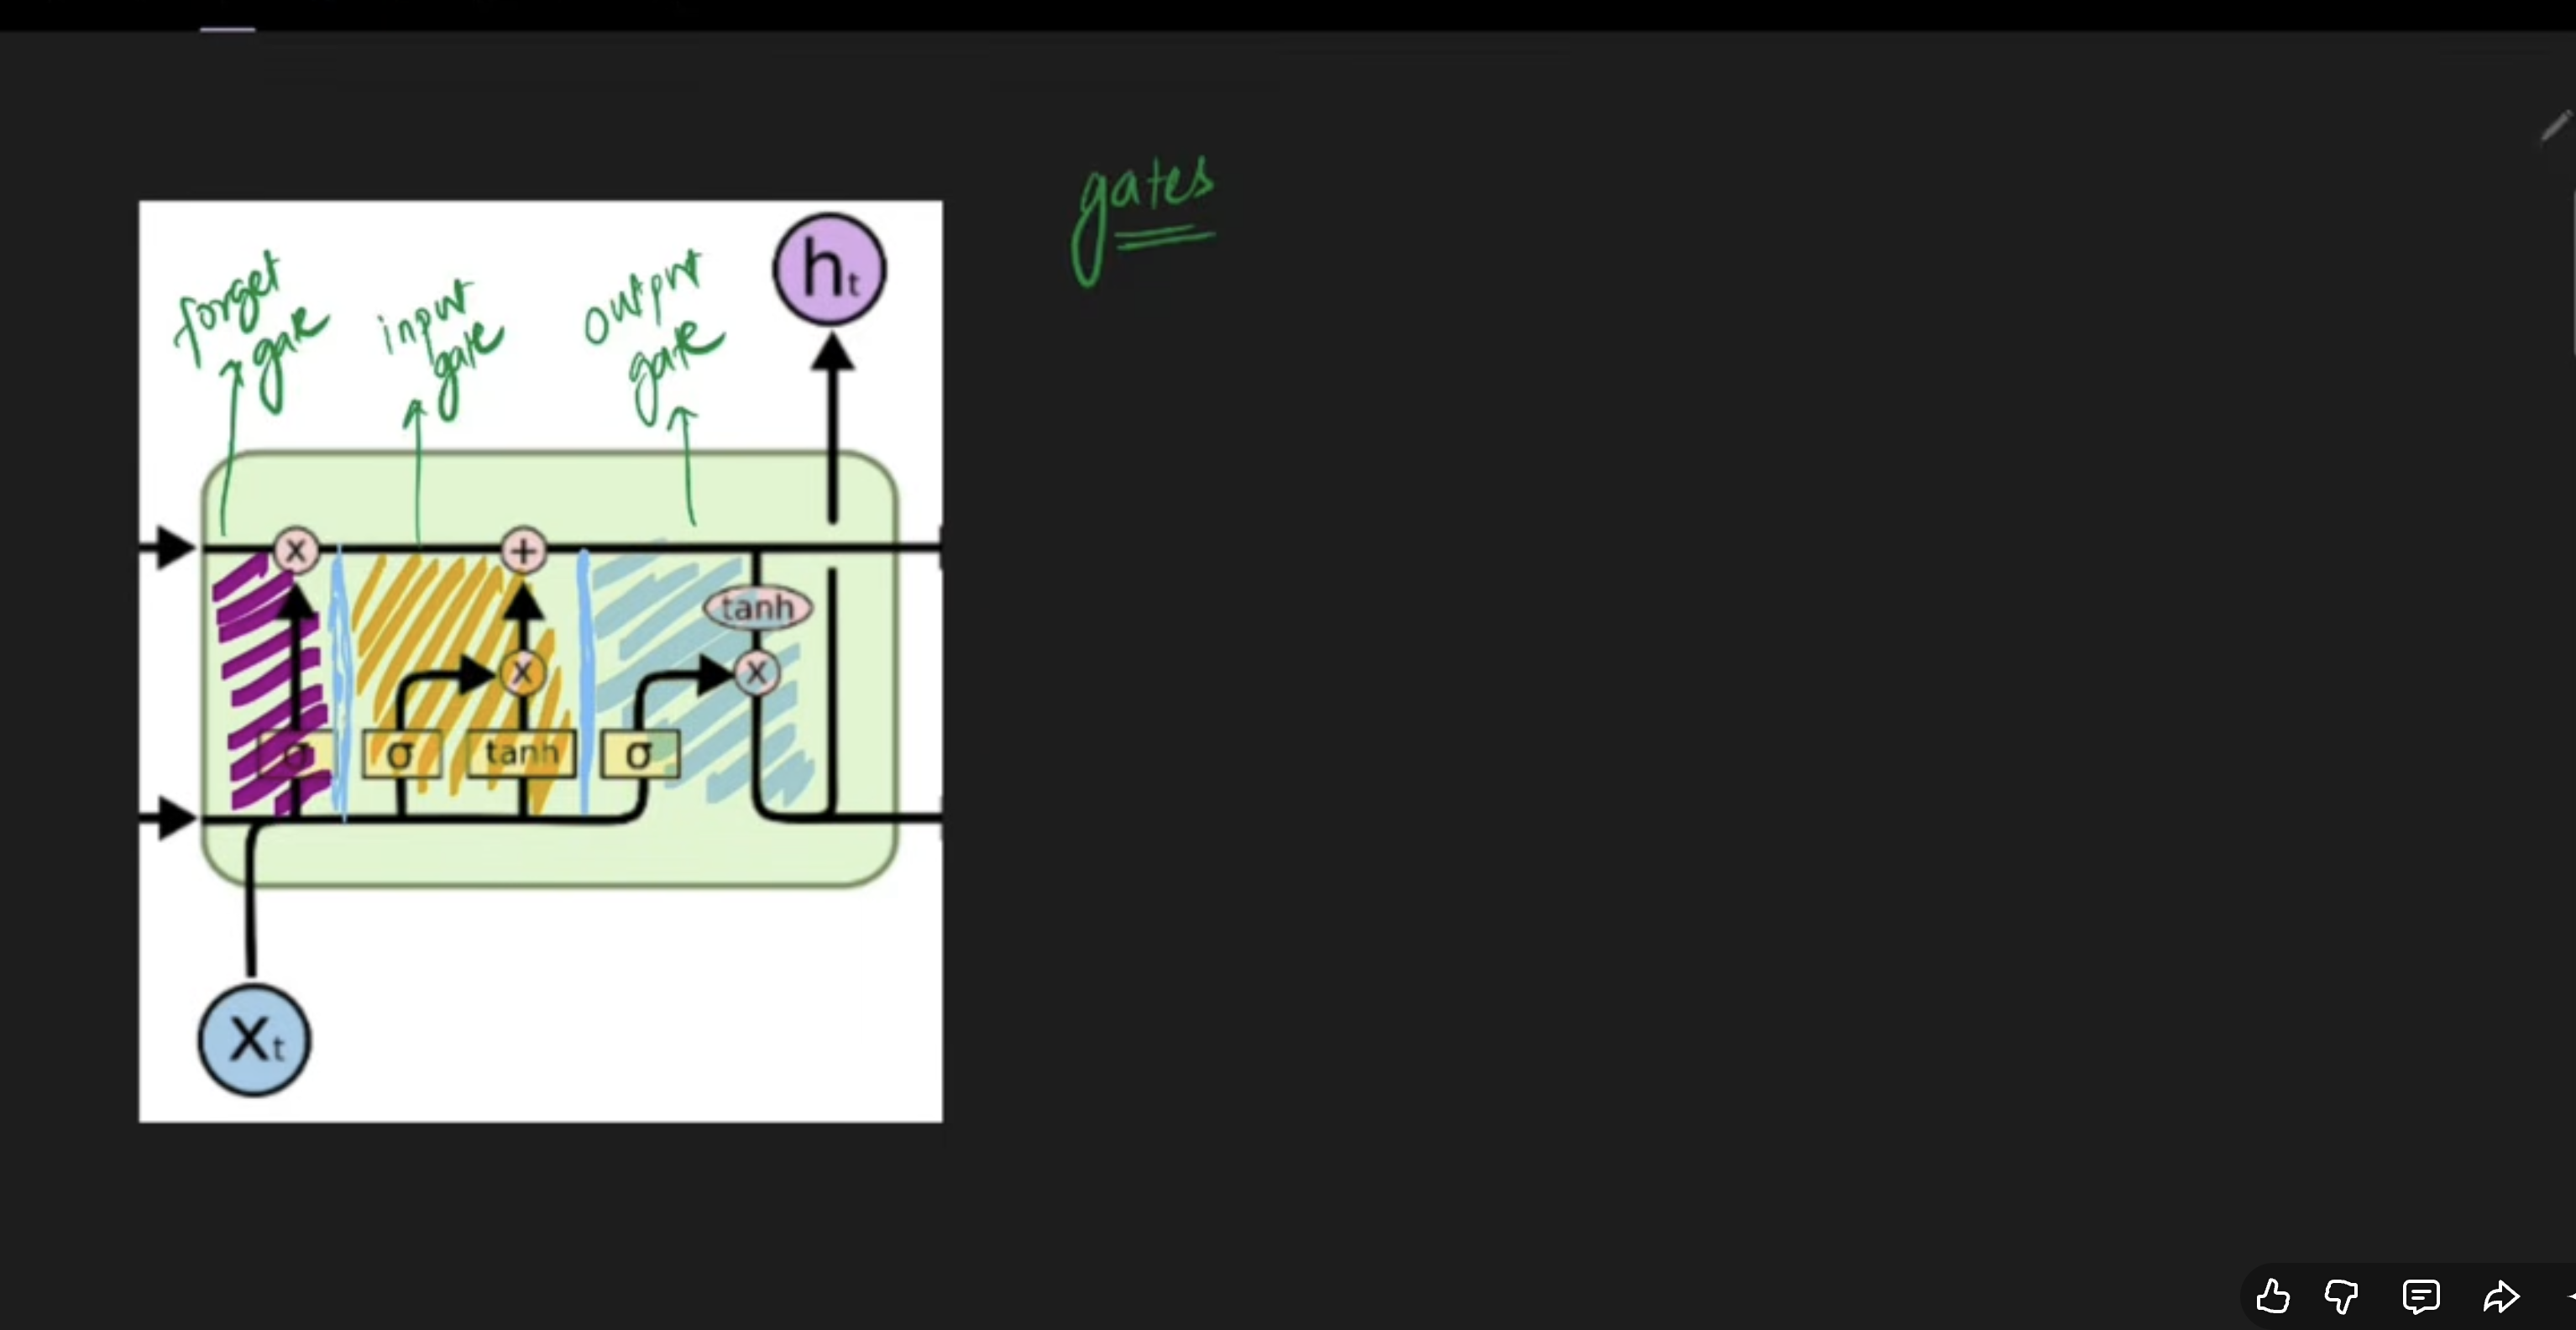
To enable communication between short-term and long-term memory, LSTM uses a **complex architecture** with **three gates**:

| Gate | Role |
|------|------|
| **Forget Gate** | Decides what to **remove** from long-term memory (based on current input + short-term memory) |
| **Input Gate** | Decides what **new information** to **add** to long-term memory |
| **Output Gate** | Decides what to **output** based on the current long-term memory |

**Simplified summary of gates:**
- **Forget Gate** → "What should I forget from the past?"
- **Input Gate** → "What new information should I remember?"
- **Output Gate** → "What should I say now based on what I remember?"

---

## 3. Key Points

- ✅ RNNs fail on long sequences due to the **vanishing gradient problem**
- ✅ LSTM solves this by using **two separate memory states**:
  - **Cell state (long-term)** – carries information across many steps
  - **Hidden state (short-term)** – carries recent context
- ✅ The two memories **communicate** through **three gates**:
  - Forget gate (removes)
  - Input gate (adds)
  - Output gate (produces output)
- ✅ LSTM processes data **one word at a time**, updating both memories at each step
- ✅ LSTM is the foundation for modern architectures like Transformers

---

## 4. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| Confusing LSTM with simple RNN | Simple RNN has only one state; LSTM has **two** (long-term + short-term) | Remember: LSTM = RNN + **extra long-term memory line** |
| Thinking gates are optional | All three gates are essential – they manage memory | Think of them as a **team**: forget, input, output |
| Forgetting the communication aspect | Gates don't work in isolation – they use both memories to decide | Always trace: "What info is the gate using to decide?" |
| Assuming LSTM is just "bigger RNN" | It's not bigger – it's **structurally different** with memory management | Focus on the **mechanism**, not just the size |

---

## 5. Interview/Exam Questions

### Q1: What is the main problem with simple RNNs that LSTM solves?
**A:** Simple RNNs suffer from the **vanishing/exploding gradient problem** when processing long sequences. This causes them to **forget early inputs**, making it difficult to capture long-term dependencies. LSTM solves this by introducing a **long-term memory (cell state)** that can carry important information across many time steps.

### Q2: What are the three gates in LSTM and what does each do?
**A:**
- **Forget Gate** – decides what information to **remove** from long-term memory
- **Input Gate** – decides what new information to **add** to long-term memory
- **Output Gate** – decides what to **output** based on the current long-term memory

### Q3: How does LSTM maintain long-term context better than RNN?
**A:** LSTM maintains a **separate cell state (long-term memory)** that runs like a "highway" through the network. Important information can travel along this highway without being overwritten by short-term context. Gates control what gets added or removed, allowing the network to **remember** important details for a long time and **forget** irrelevant ones.

### Q4: Why is LSTM considered a foundational topic for modern AI?
**A:** Modern architectures like **Transformers** (used in ChatGPT, BERT) evolved from RNN/LSTM concepts. Understanding LSTMs helps in grasping:
- How sequential data is processed
- The importance of memory/context
- The evolution towards attention mechanisms

---

## 6. Revision Notes (Quick Recap)

| Topic | Summary |
|-------|---------|
| **RNN Problem** | Forgets early inputs in long sequences due to vanishing gradients |
| **LSTM Solution** | Two memory lines – long-term (cell state) and short-term (hidden state) |
| **Forget Gate** | Removes outdated info from long-term memory |
| **Input Gate** | Adds new important info to long-term memory |
| **Output Gate** | Produces output based on current long-term memory |
| **Key Insight** | Communication between short-term and long-term memory is the core of LSTM |
| **Industry Importance** | Foundational for NLP, time series, and modern LLMs |

---

**End of Topic 1**


# Study Notes: Long Short-Term Memory (LSTM) - Part 2 (Architecture & Mathematics)

---

## 1. Introduction

### What are we covering in this topic?
Now that we understand the **conceptual idea** behind LSTM (two memories + three gates), we dive into the **actual architecture** and the **mathematics** that make it work.

### Why is this important?
- You need to know **how** the gates actually compute their decisions
- Understanding the math helps you debug models and choose hyperparameters
- It clarifies *why* LSTMs are more powerful than simple RNNs
- This knowledge is essential for implementing LSTMs from scratch or modifying them

### Real-life use
- When training an LSTM for language translation, you'll tune the gate parameters
- When your model underperforms, understanding the math helps you diagnose issues
- When reading research papers, you'll recognize LSTM equations immediately

---

## 2. Detailed Explanation

### LSTM Architecture Overview

Let's look at the complete LSTM cell. Remember: we process **one time step** at a time.

#### Inputs to an LSTM Cell (at time `t`):
| Symbol | Name | Description |
|--------|------|-------------|
| `xₜ` | Current input | The word/feature at current time step |
| `hₜ₋₁` | Previous hidden state | Short-term memory from previous step |
| `Cₜ₋₁` | Previous cell state | Long-term memory from previous step |

#### Outputs from an LSTM Cell (at time `t`):
| Symbol | Name | Description |
|--------|------|-------------|
| `hₜ` | Current hidden state | Short-term memory for next step (also used for output) |
| `Cₜ` | Current cell state | Updated long-term memory for next step |

**Important:** Even though there are 3 inputs, you get **only 2 outputs** (`hₜ` and `Cₜ`). The current input `xₜ` is consumed inside.

---

